In [2]:
# imports
import time
import math
import skrf
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import os
import subprocess

from helper import *
from pyftdi.gpio import GpioController

from idpy.instruments.keysight.fieldfox import KeysightN9917A

In [3]:
# Connect to fieldfox
fieldfox = KeysightN9917A("TCPIP::10.42.0.176::inst0::INSTR", visa_library="@py")

with fieldfox:
    print(fieldfox.id())
    print(fieldfox.errors())

Keysight Technologies,N9917A,MY53104472,A.12.56
[]


In [40]:
# Set default settings
with fieldfox:
    # change mode and wait for it to be changed (changing mode is non-blocking)
    fieldfox.mode = fieldfox.MODE.NETWORK_ANALYZER
    fieldfox.opc()

    fieldfox.average.count = 1
    fieldfox.average.mode = fieldfox.average.AVERAGE_MODE.POINT
    fieldfox.continuous()
    
    na = fieldfox.network_analyzer
    # na.window.split = na.window.WINDOW_SPLIT.SINGLE
    na.window.split = na.window.WINDOW_SPLIT.QUADRUPLE

    na.window.windows[na.WINDOW.WINDOW_1].select()
    na.window.windows[na.WINDOW.WINDOW_1].measurement = na.MEASUREMENT.S11
    na.instrument.query(f"CALCulate:SELected:FORMat SMITh;*OPC?")

    if na.window.split == na.window.WINDOW_SPLIT.QUADRUPLE:
        na.window.windows[na.WINDOW.WINDOW_2].ymin = -90
        na.window.windows[na.WINDOW.WINDOW_2].ymax = 10
        na.window.windows[na.WINDOW.WINDOW_2].measurement = na.MEASUREMENT.S21

        na.window.windows[na.WINDOW.WINDOW_3].ymin = -90
        na.window.windows[na.WINDOW.WINDOW_3].ymax = 10
        na.window.windows[na.WINDOW.WINDOW_3].measurement = na.MEASUREMENT.S12

        na.window.windows[na.WINDOW.WINDOW_4].select()
        na.window.windows[na.WINDOW.WINDOW_4].measurement = na.MEASUREMENT.S22
        na.instrument.query(f"CALCulate:SELected:FORMat SMITh;*OPC?")

    # disable all markers/tables
    fieldfox.marker.disable()

    # set range
    na.frequency.start = 100e6
    na.frequency.stop = 6e9
    na.points = int((na.frequency.stop - na.frequency.start) / 50_000_000) + 1
    na.bandwidth = na.BANDWIDTH.BW_100

In [7]:
# go through all possible configurations
configurations = [
    # 0x24, 0x27, 0x25, 0x35,
    0x09, 0x0F, 0x0B, 0x2B,
]

progress_bar = ProgressBar(len(configurations))

if not os.path.exists(f"data/n4691d"):
    os.mkdir(f"data/n4691d")

with fieldfox:
    progress_bar.total *= int(fieldfox.query("SENSe:AVERage:COUNt?"))

    for config in configurations:
        subprocess.run(['python3', 'set_state.py', str(config)])
        perform_sweep(fieldfox, progress_bar)
        ntwk = get_s1p(fieldfox)
        ntwk.write_touchstone(f"data/n4691d/eeprom-{config}.s1p")

 |██████████████████████████████████████████████████| 100.0%  (00:00:14 done)                      


In [8]:
# go through all possible configurations

# initialize calibration kit
direction = 0b0011_1111  # all but the last 2 GPIO

initial = PORT1.THRU | PORT2.THRU

gpio = GpioController()
gpio.configure("ftdi://ftdi:232h:FT07ND6B/1", direction=direction, frequency=1e3, initial=initial)

configurations: list[tuple[PORT1, PORT2]] = [
    (PORT1.LOAD, PORT2.LOAD),
    (PORT1.OPEN, PORT2.LOAD),
    (PORT1.SHORT, PORT2.LOAD),
    (PORT1.THRU, PORT2.LOAD),
    (PORT1.ATT, PORT2.LOAD),
    (PORT1.LOAD, PORT2.OPEN),
    (PORT1.LOAD, PORT2.SHORT),
    (PORT1.LOAD, PORT2.THRU),
    (PORT1.LOAD, PORT2.ATT),
    (PORT1.THRU, PORT2.THRU),
    (PORT1.ATT, PORT2.ATT),
]

# for config in range(0b11_1_1_11):
#     config_a = PORT1(config & 0b000_111)
#     config_b = PORT2(config & 0b111_000)
#     configurations.append((config_a, config_b))

progress_bar = ProgressBar(len(configurations))

if not os.path.exists(f"data/scal-2"):
    os.mkdir(f"data/scal-2")

with fieldfox:
    if fieldfox.average.mode == fieldfox.average.AVERAGE_MODE.SWEEP:
        progress_bar.total *= int(fieldfox.query("SENSe:AVERage:COUNt?"))

    for config_a, config_b in configurations:
        print(f"Setting GPIO to {config_a.name} and {config_b.name}", end='\r')
        gpio.write(config_a | config_b)
        time.sleep(1)
        perform_sweep(fieldfox, progress_bar)
        ntwk = get_s2p(fieldfox)
        ntwk.name = str(config_a | config_b)
        ntwk.write_touchstone(f"data/scal-2/eeprom-{config_a | config_b}.s2p")


 |██████████████████████████████████████████████████| 100.0%  (00:01:26 done)                      


In [7]:
gpio.close()

 |██████████████████████████████████████████████████| 100.0%  (00:00:06 done)                      


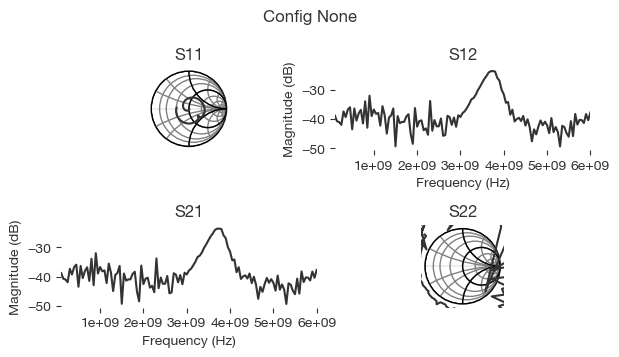

In [3]:
with fieldfox:
    perform_sweep(fieldfox)
    ntwk = get_s2p(fieldfox)

fig, axs = plt.subplots(2, 2)
fig.suptitle(f"Config {ntwk.name}")

ntwk.s11.plot_s_smith(ax=axs[0, 0])
axs[0, 0].set_title("S11")
axs[0, 0].get_legend().remove()

ntwk.s12.plot_s_db(ax=axs[0, 1])
axs[0, 1].set_title("S12")
axs[0, 1].get_legend().remove()

ntwk.s21.plot_s_db(ax=axs[1, 0])
axs[1, 0].set_title("S21")
axs[1, 0].get_legend().remove()

ntwk.s22.plot_s_smith(ax=axs[1, 1])
axs[1, 1].set_title("S22")
axs[1, 1].get_legend().remove()

fig.tight_layout()

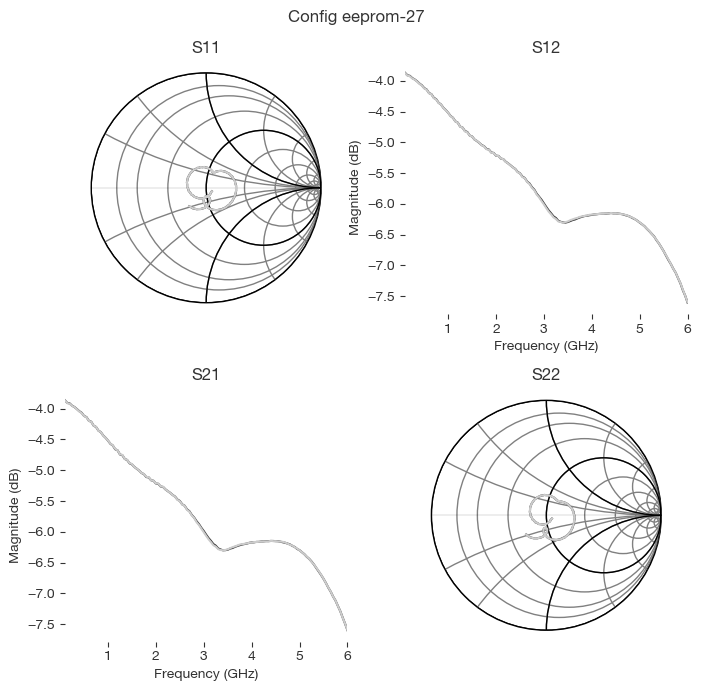

In [7]:
config = PORT1.ATT | PORT2.ATT

ntwk = skrf.Network(f"data/scal/eeprom-{config}.s2p", f_unit='GHz')
ntwk2 = skrf.Network(f"data/scal-2/eeprom-{config}.s2p", f_unit='GHz')

fig, axs = plt.subplots(2, 2, figsize=(7, 7))
fig.suptitle(f"Config {ntwk.name}")

ntwk.plot_s_smith(0, 0, ax=axs[0, 0], show_legend=False)
ntwk2.plot_s_smith(0, 0, ax=axs[0, 0], show_legend=False)
axs[0, 0].set_title("S11")

ntwk.plot_s_db(0, 1, ax=axs[0, 1], show_legend=False)
ntwk2.plot_s_db(0, 1, ax=axs[0, 1], show_legend=False)
axs[0, 1].set_title("S12")

ntwk.plot_s_db(1, 0, ax=axs[1, 0], show_legend=False)
ntwk2.plot_s_db(1, 0, ax=axs[1, 0], show_legend=False)
axs[1, 0].set_title("S21")

ntwk.plot_s_smith(1, 1, ax=axs[1, 1], show_legend=False)
ntwk2.plot_s_smith(1, 1, ax=axs[1, 1], show_legend=False)
axs[1, 1].set_title("S22")

fig.tight_layout()